# Toronto Robbery Open Data Analysis

This notebook reproduces the Excel analysis in Python using pandas, NumPy, and Matplotlib.
Goals:
- Clean and reorganize the Toronto robbery dataset
- Restrict analysis to 2014–2025
- Count distinct incidents using EVENT_UNIQUE_ID
- Recreate the main Excel PivotTables with groupby() and pivot_table()
- Create portfolio-ready charts and heatmaps

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

### 1. Load the dataset:

In [3]:
file_path = 'Robbery_Open_Data.csv'  # update if needed
df = pd.read_csv(file_path)

print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()

Rows: 40885
Columns: 31


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,UCR_CODE,UCR_EXT,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262644,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,14,2014.0,January,1.0,1.0,Wednesday,14,D12,"Apartment (Rooming House, Condo)",Apartment,1610,150,Robbery - Purse Snatch,Robbery,113,Weston (113),113,Weston (113),-79.516192,43.700155,-8.851702e+06,5.419157e+06
1,2,GO-20141262818,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,14,2014.0,January,1.0,1.0,Wednesday,3,D51,Other Commercial / Corporate Places (For Profi...,Commercial,1610,210,Robbery - Business,Robbery,167,Church-Wellesley (167),075,Church-Yonge Corridor (75),-79.384137,43.663899,-8.837002e+06,5.413576e+06
2,3,GO-20141260912,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,6,2014.0,January,1.0,1.0,Wednesday,4,D14,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,100,Robbery With Weapon,Robbery,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),-79.401983,43.647598,-8.838988e+06,5.411068e+06
3,4,GO-20141260577,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,4,2014.0,January,1.0,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,200,Robbery - Mugging,Robbery,NSA,NSA,NSA,NSA,0.000000,0.000000,6.327780e-09,5.664924e-09
4,5,GO-20141260577,1/1/2014 5:00:00 AM,1/1/2014 5:00:00 AM,2014,January,1,1,Wednesday,4,2014.0,January,1.0,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,1610,180,Robbery - Swarming,Robbery,NSA,NSA,NSA,NSA,0.000000,0.000000,6.327780e-09,5.664924e-09


### 2. Keep the columns used in the Excel Report

In [4]:
keep_columns = [
    'EVENT_UNIQUE_ID', 'OCC_DATE', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY',
    'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE',
    'OFFENCE', 'HOOD_158', 'NEIGHBOURHOOD_158', 'LONG_WGS84', 'LAT_WGS84'
]

df = df[keep_columns].copy()
df.head()

,EVENT_UNIQUE_ID,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DAY,OCC_DOW,OCC_HOUR,DIVISION,LOCATION_TYPE,PREMISES_TYPE,OFFENCE,HOOD_158,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84
0,GO-20141262644,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,14,D12,"Apartment (Rooming House, Condo)",Apartment,Robbery - Purse Snatch,113,Weston (113),-79.516192,43.700155
1,GO-20141262818,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,3,D51,Other Commercial / Corporate Places (For Profi...,Commercial,Robbery - Business,167,Church-Wellesley (167),-79.384137,43.663899
2,GO-20141260912,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,4,D14,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery With Weapon,078,Kensington-Chinatown (78),-79.401983,43.647598
3,GO-20141260577,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery - Mugging,NSA,NSA,0.000000,0.000000
4,GO-20141260577,1/1/2014 5:00:00 AM,2014.0,January,1.0,Wednesday,2,NSA,"Streets, Roads, Highways (Bicycle Path, Privat...",Outside,Robbery - Swarming,NSA,NSA,0.000000,0.000000


### 3. Clean and Reorganize the Data:

In [7]:
df['OCC_DATE'] = pd.to_datetime(df['OCC_DATE'], errors='coerce')
df['OCC_YEAR'] = pd.to_numeric(df['OCC_YEAR'], errors='coerce').astype('Int64')
df['OCC_DAY'] = pd.to_numeric(df['OCC_DAY'], errors='coerce').astype('Int64')
df['OCC_HOUR'] = pd.to_numeric(df['OCC_HOUR'], errors='coerce').astype('Int64')
df['LONG_WGS84'] = pd.to_numeric(df['LONG_WGS84'], errors='coerce')
df['LAT_WGS84'] = pd.to_numeric(df['LAT_WGS84'], errors='coerce')

df['DASHBOARD_YEAR'] = df['OCC_YEAR'].where(
    df['OCC_YEAR'].between(2014, 2025)
)

analysis_df = df[df['OCC_YEAR'].between(2014, 2025)].copy()

print('Analysis rows:', len(analysis_df))
print('Distinct incidents:', analysis_df['EVENT_UNIQUE_ID'].nunique())

Analysis rows: 39598
Distinct incidents: 31320


### 4. Basic data-quality checks

In [9]:
quality_check = pd.DataFrame({
    'missing_values': analysis_df.isna().sum(),
    'unique_values': analysis_df.nunique(dropna=True)
}).sort_values('missing_values', ascending=False)

quality_check

,missing_values,unique_values
PREMISES_TYPE,1,7
LOCATION_TYPE,1,51
EVENT_UNIQUE_ID,0,31320
OCC_DATE,0,4364
OCC_DAY,0,31
OCC_DOW,0,7
OCC_YEAR,0,12
OCC_MONTH,0,12
DIVISION,0,18
OCC_HOUR,0,24


### 5. Robbery incidents by year

In [10]:
incidents_by_year = (
    analysis_df.groupby('OCC_YEAR')['EVENT_UNIQUE_ID']
    .nunique()
    .reset_index(name='Distinct_Incidents')
)

incidents_by_year

,OCC_YEAR,Distinct_Incidents
0,2014,2998
1,2015,2870
2,2016,3048
3,2017,3214
4,2018,3055
5,2019,2960
6,2020,2215
7,2021,1802
8,2022,2207
9,2023,2424


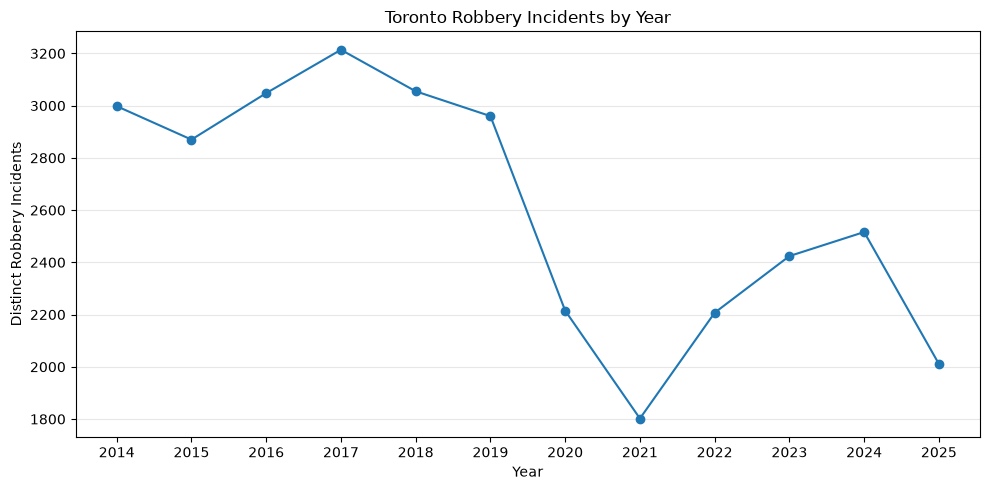

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(incidents_by_year['OCC_YEAR'], incidents_by_year['Distinct_Incidents'], marker='o')
plt.title('Toronto Robbery Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Distinct Robbery Incidents')
plt.xticks(incidents_by_year['OCC_YEAR'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Top 10 neighbourhoods by distinct robbery incidents

In [12]:
top_neighbourhoods = (
    analysis_df[analysis_df['NEIGHBOURHOOD_158'].ne('NSA')]
    .groupby('NEIGHBOURHOOD_158')['EVENT_UNIQUE_ID']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods

NEIGHBOURHOOD_158
Moss Park (73)                           1117
Downtown Yonge East (168)                 976
West Humber-Clairville (1)                717
Yonge-Bay Corridor (170)                  638
York University Heights (27)              632
Mount Olive-Silverstone-Jamestown (2)     585
Kensington-Chinatown (78)                 579
West Hill (136)                           554
Church-Wellesley (167)                    475
Annex (95)                                449
Name: EVENT_UNIQUE_ID, dtype: int64

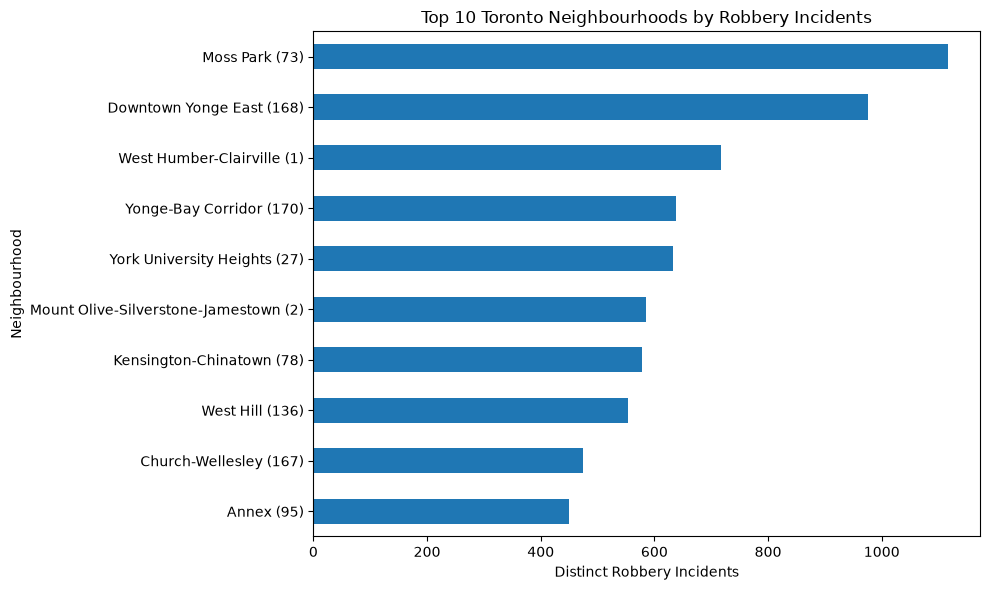

In [13]:
plt.figure(figsize=(10, 6))
top_neighbourhoods.sort_values().plot(kind='barh')
plt.title('Top 10 Toronto Neighbourhoods by Robbery Incidents')
plt.xlabel('Distinct Robbery Incidents')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

### 7. Year × Premises Type

In [14]:
year_premises = pd.pivot_table(
    analysis_df,
    index='OCC_YEAR',
    columns='PREMISES_TYPE',
    values='EVENT_UNIQUE_ID',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

year_premises

PREMISES_TYPE,Apartment,Commercial,Educational,House,Other,Outside,Transit
OCC_YEAR,,,,,,,
2014,271,546,111,65,49,1875,81
2015,287,604,70,76,60,1712,61
2016,236,711,96,80,56,1786,83
2017,295,785,87,82,89,1772,104
2018,244,864,74,70,79,1617,107
2019,245,802,77,87,82,1582,85
2020,158,789,45,62,90,980,91
2021,184,521,41,49,99,835,73
2022,186,681,46,69,183,955,87


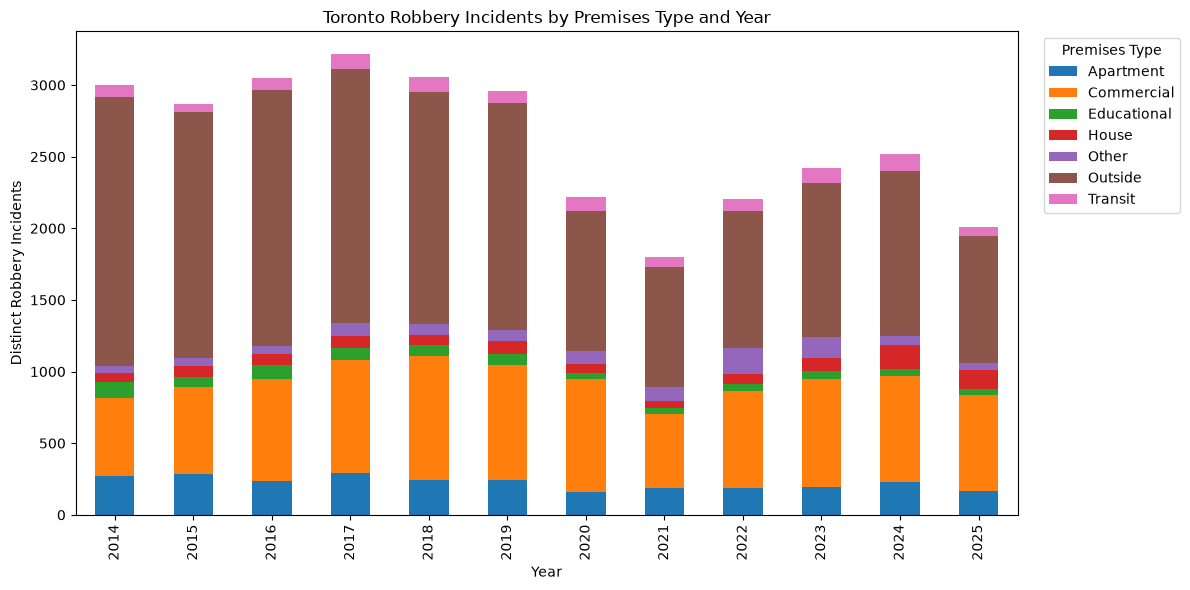

In [15]:
year_premises.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Toronto Robbery Incidents by Premises Type and Year')
plt.xlabel('Year')
plt.ylabel('Distinct Robbery Incidents')
plt.legend(title='Premises Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8. Day of Week × Hour heatmap

### 9. Offence Type × Premises Type

### 10. Top neighbourhoods × major offence types

### 11. Top 5 Police Divisions × Year

### 12. Export cleaned data and analysis tables

### 13. Portfolio insights